In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
from pathlib import Path

root = Path.cwd().resolve().parent
sys.path.insert(0, str(root))
print("Setting root of the project to:", root)
print("This means we can bring in models from other directories (like ./models)")

Setting root of the project to: /home/kv/education/predicting_DFE
This means we can bring in models from other directories (like ./models)


In [8]:

# Read a single allele frequency, i.e., "0:200:0:1:0:0"
def alleleFrequency(base, allele_count):
    # Allele count format: [A : T : C : G : N : del]
    base_dict = {
        'A': 0,
        'T': 1,
        'C': 2,
        'G': 3,
        'N': 4,   # unused
        'del': 5  # unsued, both defined to be explicit
    }
    base_index = base_dict.get(base)
    vector = [int(num) for num in allele_count.split(':')]

    # Sum all values
    total = sum(vector)

    # Error-handle for division-by-zero
    if total == 0:
        return 0.0

    # Find difference between base & total
    base_value = vector[base_index]
    mutations = total - base_value
    freq = mutations / total
    return freq;


In [9]:
columns = [
    'chromosome',
    'position',
    'base',
    'Dsim_Fl_Base_1',
    'Dsim_Fl_Hot_F10_1',
    'Dsim_Fl_Hot_F20_1', 
    'Dsim_Fl_Hot_F30_1',
    'Dsim_Fl_Hot_F40_1', 
    'Dsim_Fl_Hot_F50_1', 
    'Dsim_Fl_Hot_F60_1'
]

real_df = pd.read_csv(
    filepath_or_buffer="../data/chromosome_2L.sync",
    sep='\t', # tab-separated values
    names=columns,
    usecols=columns,
    header=None # no headers provided
)

rename_dict = {
    'Dsim_Fl_Base_1':    'gen_0',
    'Dsim_Fl_Hot_F10_1': 'gen_10',
    'Dsim_Fl_Hot_F20_1': 'gen_20',
    'Dsim_Fl_Hot_F30_1': 'gen_30',
    'Dsim_Fl_Hot_F40_1': 'gen_40',
    'Dsim_Fl_Hot_F50_1': 'gen_50',
    'Dsim_Fl_Hot_F60_1': 'gen_60'
}

# Rename the columns (inplace=True modifies the original DataFrame)
real_df.drop(columns=['chromosome'], inplace=True)
real_df.rename(columns=rename_dict, inplace=True)

for column in ['gen_0','gen_10','gen_20','gen_30','gen_40','gen_50','gen_60']:
    real_df[column] = [
        alleleFrequency(b, c) 
        for b, c in zip(real_df['base'], real_df[column])
    ]    

In [12]:
sim_df = pd.DataFrame()
sim_df['position'] = pd.read_csv("../slim/inputs/admixture_mapping_targets.csv", header=None)

for generation in range(1, 7):
    sim_i = pd.read_csv(f"../slim/outputs/65755-70000-0-_Cycle_{generation}0.txt")
    sim_df[f"sim_{generation}0"] = sim_i[f"Frequency_{generation}0"]

sim_df

,position,sim_10,sim_20,sim_30,sim_40,sim_50,sim_60
0,1000020,0,0,0,0,0,0
1,1000025,0,0,0,0,0,0
2,1000034,0,0,0,0,0,0
3,1000045,0,0,0,0,0,0
4,1000063,0,0,0,0,0,0
...,...,...,...,...,...,...,...
69995,2458912,0,0,0,0,0,0
69996,2458931,0,0,0,0,0,0
69997,2458939,0,0,0,0,0,0
69998,2458947,0,0,0,0,0,0


In [13]:
df = sim_df.melt(
    id_vars=['position'],
    value_vars=['sim_10', 'sim_20', 'sim_30', 'sim_40', 'sim_50', 'sim_60'],
    var_name='time',
    value_name='mutations',
)
df['time'] = df['time'].str.replace("sim_", "").astype(int)
df

,position,time,mutations
0,1000020,10,0
1,1000025,10,0
2,1000034,10,0
3,1000045,10,0
4,1000063,10,0
...,...,...,...
419995,2458912,60,0
419996,2458931,60,0
419997,2458939,60,0
419998,2458947,60,0


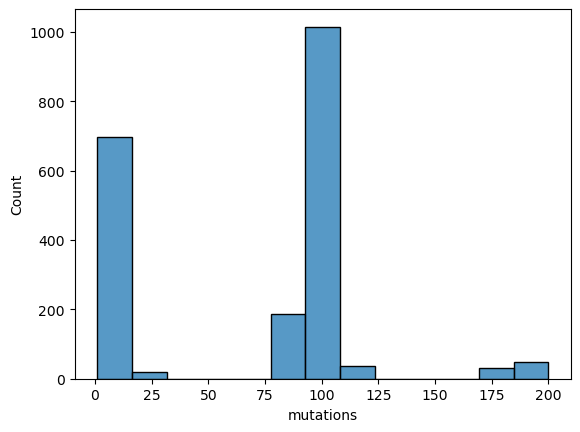

In [16]:
sns.histplot(data=df[df.mutations != 0], x='mutations')
plt.show()

In [57]:
df = df.sort_values(by=['position', 'time'])
df['next_delta'] = 

,position,time,mutations
0,10194546,10,0
10000,10194546,20,0
20000,10194546,30,0
30000,10194546,40,0
40000,10194546,50,0
...,...,...,...
19999,12510955,20,0
29999,12510955,30,0
39999,12510955,40,0
49999,12510955,50,0


AttributeError: This method only works with the ScalarFormatter

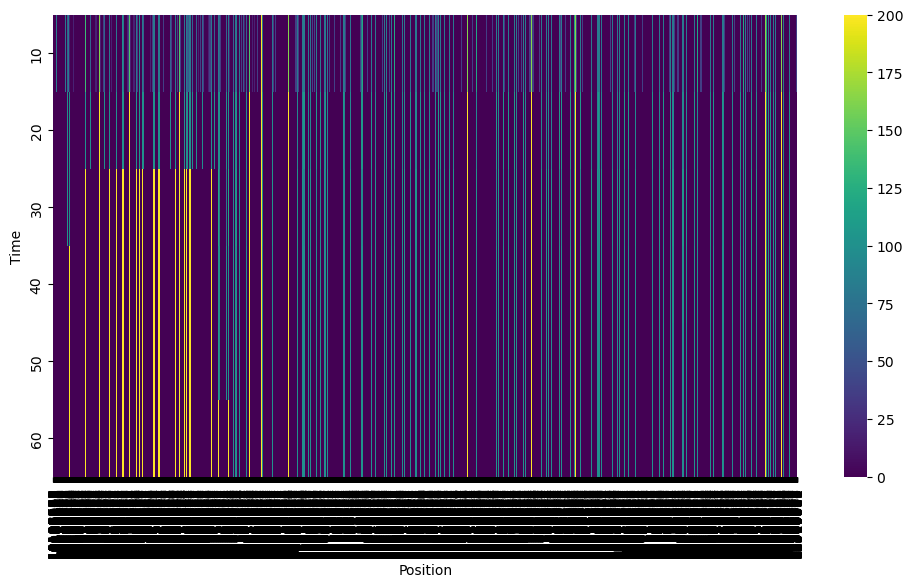

In [55]:
df_pivot = df.pivot(index="time", columns="position", values="mutations")

# 2. Setup the matplotlib figure
plt.figure(figsize=(12, 6))

# 3. Plot using the raw values to keep Seaborn fast and stable.
# xticklabels=1000 tells it to only draw every 1000th position label so they don't overlap.
ax = sns.heatmap(
    df_pivot.values,
    xticklabels=df_pivot.columns,
    yticklabels=df_pivot.index,
    cmap="viridis",
)

# 4. Clean up the axes so they don't use scientific notation
ax.set_xlabel("Position")
ax.set_ylabel("Time")
ax.ticklabel_format(style="plain", axis="x")

# Rotate labels so they are readable
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

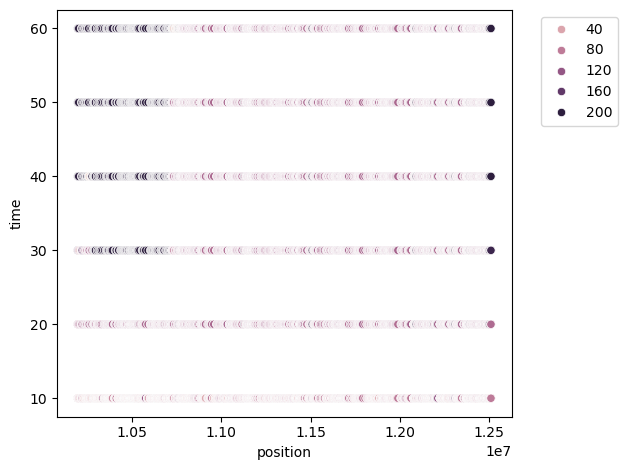

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

# sns.heatmap(data=df, x='position', y='time', hue='mutations')
sns.scatterplot(data=df[df.mutations > 0], x='position', y='time', hue='mutations')
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [18]:
real_df = pd.read_csv("../slim/inputs/real_frequencies.csv")
merged_df = pd.merge(sim_df, real_df, on='position', how='left')
merged_df
# real_df

,position,sim_10,sim_20,sim_30,sim_40,sim_50,sim_60,base,gen_0,gen_10,gen_20,gen_30,gen_40,gen_50,gen_60
0,1000020,0,0,0,0,0,0,G,0.287425,0.327485,0.343750,0.321429,0.333333,0.342697,0.324022
1,1000025,0,0,0,0,0,0,T,0.041420,0.045977,0.040724,0.018182,0.038298,0.035503,0.011050
2,1000034,0,0,0,0,0,0,T,0.111842,0.114286,0.159624,0.197605,0.134783,0.113208,0.129213
3,1000045,0,0,0,0,0,0,T,0.165563,0.127907,0.125000,0.162338,0.164557,0.169935,0.109091
4,1000063,0,0,0,0,0,0,G,0.064935,0.059172,0.038298,0.046980,0.047059,0.034247,0.106509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,2458912,0,0,0,0,0,0,T,0.189055,0.098901,0.148789,0.120192,0.115282,0.110577,0.102439
69996,2458931,0,0,0,0,0,0,T,0.563107,0.580110,0.543253,0.638393,0.611732,0.591133,0.624365
69997,2458939,0,0,0,0,0,0,G,0.187500,0.158470,0.124161,0.129630,0.150418,0.166667,0.162437
69998,2458947,0,0,0,0,0,0,A,0.004651,0.010929,0.006645,0.008811,0.002725,0.004717,0.019417
